# E2 — ISIC 2017 UNet2D Architecture Tie-Break (10 seeds)

**Question.** Between `classical + he2` and `classical + attention_gate` (both at `lr = 3e-4`), which architecture produces the better segmentation model?

**Design.** 10 shared seeds (100–109). Within each seed both architectures share weight initialisation and data ordering, so the *only* difference inside a seed pair is the architecture. We therefore analyse the **paired** differences Δᵢ = AGᵢ − HE2ᵢ.

**Source.** `E2-isic2017-unet2d-model-tiebreak-5seed.db` (seeds 100–104) + `…_part2.db` (seeds 105–109) — 20 runs (2 architectures × 10 seeds), all `FINISHED`.

## Executive summary

Paired across 10 shared seeds. Δ = AG − HE2; primary test = Wilcoxon signed-rank; CI = BCa bootstrap 95 % (10 000 resamples, `rng=42`); d_z = Cohen's paired effect size.

| Metric | AG | HE2 | Δ (AG−HE2) | 95 % BCa CI | Wilcoxon p | d_z | Verdict |
|---|---|---|---|---|---|---|---|
| **Plateau Dice** — *primary* † | 0.8300 | 0.8275 | **+0.0025** | [+0.0006, +0.0048] | **0.037** | +0.70 | **AG** ✓ |
| Peak Dice | 0.8458 | 0.8464 | −0.0006 | [−0.0024, +0.0009] | 0.70 | −0.20 | tie |
| Peak IoU | 0.7392 | 0.7397 | −0.0005 | [−0.0035, +0.0022] | 0.85 | −0.10 | tie |
| Gen-gap *(lower = better)* | 0.0921 | 0.0945 | −0.0024 | [−0.0068, +0.0030] | 0.38 | −0.29 | tie |
| Throughput ‡ | 119.7 sps | 135.3 sps | −15.6 (−13 %) | [−17.3, −12.7] | **0.002** | −4.1 | **HE2** ✓ |

† Pre-registered primary; tested standalone (k = 1, α = 0.05).  ‡ Training-cost hypothesis; standalone (k = 1, α = 0.05). Secondary quality metrics {Peak Dice, Peak IoU, Gen-gap} form a Holm family (k = 3) — none significant.

**Finding.** AG wins the pre-registered primary (plateau Dice: p = 0.037, CI excludes 0, d_z = +0.70, 8/10 seeds), but the margin is small and the parametric cross-check is borderline (paired t-test p = 0.054). Peak Dice and IoU are a practical tie (|Δ| < 0.001). HE2 trains 13 % faster — its only confirmed edge.

**Decision: lock `classical + attention_gate` at `lr = 3e-4`.** AG holds the one confirmed model-quality axis; `he2` remains a defensible fallback when training throughput is the binding constraint.

> **Caveat.** All metrics are validation-only. Test-set evaluation is required before any deployment claim.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path('/teamspace/studios/this_studio/repos/SkiNet')
sys.path.insert(0, str(PROJECT_ROOT))

from SkiNet.Utils.analysis.aggregation import load_runs
from SkiNet.Utils.analysis.stats import build_comparison_table
from SkiNet.Utils.analysis.reporting import (
    show_run_table, show_comparison_table, show_family_verdicts,
)
from SkiNet.Utils.analysis.plotting import (
    set_paper_style, plot_paired_slopegraph, plot_paired_forest,
)

# ── Configuration — every tunable argument lives in this cell ────────────────
FIG_DIR  = PROJECT_ROOT / 'analysis_results'
DB_PATHS = [
    PROJECT_ROOT / 'mlruns' / 'E2-isic2017-unet2d-model-tiebreak-5seed.db',        # seeds 100–104
    PROJECT_ROOT / 'mlruns' / 'E2-isic2017-unet2d-model-tiebreak-5seed_part2.db',  # seeds 105–109
]

AG, HE2 = 'classical+attention_gate', 'classical+he2'
EXP_MAP = {1: HE2, 2: AG}                       # MLflow experiment_id → architecture
PALETTE = {AG: '#d1495b', HE2: '#30638e'}

ALPHA   = 0.05
N_BOOT  = 10_000
RNG     = np.random.default_rng(42)

PRIMARY_METRIC    = 'val_dice_tail_mean'
SECONDARY_METRICS = ['val_dice_max', 'val_iou_max', 'generalization_gap_final']
# (metric, higher_is_better, family_size_k)
METRICS_SPEC = [
    ('val_dice_max',             True,  len(SECONDARY_METRICS)),
    ('val_iou_max',              True,  len(SECONDARY_METRICS)),
    ('val_dice_tail_mean',       True,  1),
    ('generalization_gap_final', False, len(SECONDARY_METRICS)),
    ('samples_per_sec',          True,  1),
]

RUN_TABLE_COLS = ['arch', 'seed', 'val_dice_max', 'val_dice_tail_mean',
                  'val_dice_tail_std', 'val_iou_max', 'generalization_gap_final',
                  'samples_per_sec', 'duration_min']
SLOPE_METRICS = [
    ('val_dice_max',       'Peak Dice (best checkpoint)'),
    ('val_dice_tail_mean', 'Plateau Dice (last-10-epoch mean)'),
]
FOREST_SPECS = [
    ('Peak Dice',         'val_dice_max',             False),
    ('Peak IoU',          'val_iou_max',              False),
    ('Plateau Dice',      'val_dice_tail_mean',       False),
    ('Gen-gap reduction', 'generalization_gap_final', True),
]

# ── Presentation ─────────────────────────────────────────────────────────────
set_paper_style(context='notebook')
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Load: 20 runs = 2 architectures × 10 seeds ───────────────────────────────
runs = load_runs(*DB_PATHS, exp_map=EXP_MAP)
SEEDS, N = sorted(runs['seed'].unique()), runs['seed'].nunique()

Loaded 20 runs: {'classical+he2': 10, 'classical+attention_gate': 10} | seeds: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]


## 1. Data

One row per (seed, architecture). Columns:

- **`val_dice_max`** — peak Dice of the best-saved checkpoint (the model that would actually be deployed).
- **`val_dice_tail_mean` / `…_std`** — mean and SD of Dice over the last 10 epochs: the convergent *plateau* level and its noise.
- **`val_iou_max`** — peak IoU of the best checkpoint.
- **`generalization_gap_final`** — final `train_dice − val_dice` (overfitting signal; lower is better).
- **`samples_per_sec` / `duration_min`** — training throughput and wall-clock cost.

In [2]:
show_run_table(runs, RUN_TABLE_COLS)

,arch,seed,val_dice_max,val_dice_tail_mean,val_dice_tail_std,val_iou_max,generalization_gap_final,samples_per_sec,duration_min
0,classical+attention_gate,100,0.8446,0.8323,0.0091,0.7375,0.0836,120.6179,47.9777
1,classical+attention_gate,101,0.8421,0.8270,0.0075,0.7350,0.0895,120.2251,44.7637
2,classical+attention_gate,102,0.8459,0.8295,0.0141,0.7402,0.0932,119.1804,44.9632
3,classical+attention_gate,103,0.8471,0.8360,0.0088,0.7416,0.0926,121.8578,45.0704
4,classical+attention_gate,104,0.8461,0.8294,0.0098,0.7385,0.1012,122.7619,44.9806
5,classical+attention_gate,105,0.8500,0.8287,0.0164,0.7446,0.0725,116.9509,46.6895
6,classical+attention_gate,106,0.8475,0.8295,0.0080,0.7417,0.0979,119.1532,45.3808
7,classical+attention_gate,107,0.8460,0.8345,0.0074,0.7397,0.0811,116.8750,46.6754
8,classical+attention_gate,108,0.8437,0.8272,0.0110,0.7356,0.1094,119.5617,46.8568
9,classical+attention_gate,109,0.8450,0.8263,0.0067,0.7371,0.1004,119.6275,46.7054


## 2. Statistical methods

### 2.1 Why a *paired* design

Within each seed, AG and HE2 share weight initialisation and data ordering, so everything that varies run-to-run *except the architecture* is held constant. Subtracting within the pair, Δᵢ = AGᵢ − HE2ᵢ, cancels that shared seed noise and isolates the architecture effect. We analyse the 10 paired differences {Δᵢ}, not the two groups separately — far more sensitive at small n.

> **Scope caveat.** All seeds reuse a single fixed ISIC-2017 train/validation split; only initialisation varies — this is *not* k-fold cross-validation. Per Rainio et al. (2024), fixed-split p-values can understate variance, so treat every interval and p-value below as an **optimistic lower bound** on the true uncertainty.

### 2.2 Three independent hypothesis families

Each family controls its own family-wise error rate at α = 0.05, so a win in one never borrows evidence from another.

| Family | Metric(s) | k | Per-metric threshold | Correction |
|---|---|---|---|---|
| **Primary (pre-registered)** | `val_dice_tail_mean` | 1 | **0.05** | none — standalone |
| **Secondary quality** | `val_dice_max`, `val_iou_max`, gen-gap | 3 | ≤ **0.0167** | Holm step-down |
| **Training cost** | `samples_per_sec` | 1 | **0.05** | none — standalone |

*Why plateau Dice is primary:* it measures the **stable, convergent** Dice level (mean of the last 10 epochs) rather than a single lucky peak checkpoint, and it was fixed as the endpoint **before** the data were seen — so its α is not spent on multiple looks.

### 2.3 Inference criteria — how to read each number

Three complementary lenses on the same 10 paired differences. The **test** asks *is there an effect?*; the **CI** asks *how big, and in which direction?*; **d_z** asks *how big relative to the noise?* A claim is strong only when all three agree.

#### ① Wilcoxon signed-rank test — “Is there an effect at all?”

- **Plain language:** rank the 10 differences by magnitude, then check whether the positive and negative ones are balanced. If the two architectures were truly equal, large differences would land on each side about equally; a lopsided pile-up is evidence of a real effect.
- **Null hypothesis H₀:** the population median of Δᵢ is 0.
- **Statistic:** T = min(W⁺, W⁻), the smaller of the summed positive / negative ranks. Small T ⇒ the non-zero differences are both *one-sided* **and** carried by the *larger* magnitudes — it weights sign consistency and magnitude jointly.
- **Why this test:** non-parametric (no normality assumption), robust to the odd outlier seed typical of small ML sweeps, and the test Rainio et al. recommend for comparing segmentation models across repeated runs.
- **Reject H₀ when** the exact two-tailed p < the family threshold (§2.2).
- **Resolution limit at n = 10:** the smallest achievable two-tailed p is 2 / 2¹⁰ = **0.00195**, reached only when all 10 differences share one sign. Both α thresholds sit safely above this floor, so the test has room to reject.

#### ② BCa bootstrap 95 % CI — “How large is the effect, and is its direction reliable?”

- **Plain language:** resample the 10 differences *with replacement* 10 000 times, recompute the mean each time, and read off the middle 95 % of those means. This traces the sampling distribution of mean(Δ) straight from the data instead of assuming a formula.
- **Target:** mean(Δ). (The Wilcoxon test targets the *median* rank — reporting both guards against skew.)
- **BCa = bias-corrected and accelerated**, two corrections on top of the raw percentile interval:
  - **bias (b̂)** — shifts both endpoints when the bootstrap means sit systematically above/below the observed mean;
  - **acceleration (â)** — stretches one tail more than the other (estimated by leave-one-out jackknife) when the estimator's variance changes with its value.
  - Net effect: the interval is deliberately **asymmetric** around the point estimate when Δ is skewed or n is small — preferred over the plain percentile method at n = 10.
- **Read it as:** CI **excludes 0** ⇒ the *sign* of the effect is reliable at 95 %; CI **straddles 0** ⇒ direction undetermined. The interval *width* is the honest precision — wide intervals at n = 10 are expected, not a defect.

#### ③ Cohen's d_z — “Is the effect big relative to the noise it had to beat?”

$$d_z = \frac{\overline{\Delta}}{\mathrm{SD}(\Delta,\ \mathrm{ddof}=1)}$$

- **Plain language:** the mean difference expressed in units of its own seed-to-seed scatter — a signal-to-noise ratio for the paired effect.
- **Paired denominator:** the SD of the *differences*, not the pooled SD of the two groups. Because pairing already removed the shared seed variance, SD(Δ) is small, so d_z is *larger* than an unpaired Cohen's d for the same raw gap — correctly crediting the variance the design eliminated.
- **Scale (Cohen 1988):** < 0.2 negligible · 0.2–0.5 small · 0.5–0.8 medium · > 0.8 large. Reported with its own bootstrap 95 % CI, since at n = 10 the point estimate is imprecise.

## 3. Results

In [3]:
results = build_comparison_table(
    runs, METRICS_SPEC,
    arch_a=AG, arch_b=HE2, seeds=SEEDS,
    alpha=ALPHA, n_resamples=N_BOOT, random_state=RNG,
)
show_comparison_table(results)
show_family_verdicts(results, PRIMARY_METRIC, SECONDARY_METRICS, alpha=ALPHA)

,AG,HE2,Δ (AG−HE2),95% BCa CI,p,sig,d_z
metric,,,,,,,
val_dice_max,0.8458,0.8464,-0.0006,"[-0.0024, +0.0009]",0.6953,,-0.2000
val_iou_max,0.7392,0.7397,-0.0005,"[-0.0035, +0.0022]",0.8457,,-0.1000
val_dice_tail_mean,0.8300,0.8275,+0.0025,"[+0.0006, +0.0048]",0.0371,✓,0.7000
generalization_gap_final,0.0921,0.0945,-0.0024,"[-0.0068, +0.0030]",0.3750,,-0.2900
samples_per_sec,119.6811,135.2819,-15.6007,"[-17.3005, -12.7333]",0.0020,✓,-4.1400


Primary  val_dice_tail_mean  (k=1, α=0.05):
  p=0.0371  →  REJECT H0 ✓

Holm step-down  secondary family  (k=3, α_adj=0.0167):
                              p  threshold  reject
test                                              
generalization_gap_final 0.3750     0.0167   False
val_dice_max             0.6953     0.0250   False
val_iou_max              0.8457     0.0500   False

Throughput  samples_per_sec  (k=1, α=0.05):
  p=0.0020  →  REJECT H0 ✓


### 3.1 What the table says

- **Plateau Dice (primary).** Wilcoxon p = 0.037 rejects H₀; BCa CI [+0.0006, +0.0048] excludes 0; d_z = +0.70 (medium), 95 % CI [+0.01, +1.24]; AG higher on 8/10 seeds. The parametric paired t-test (cross-check only) gives p = 0.054 — just outside α. The effect is therefore **real but modest**, exactly what a medium d_z with a CI that nearly touches 0 implies.
- **Peak Dice / Peak IoU.** Ties — |Δ| < 0.001, p ≥ 0.70, CIs span 0, an even 5/5 seed split. These are the *deployed-checkpoint* metrics, so the architectures are interchangeable on what ships.
- **Generalisation gap.** AG lower on 7/10 seeds, but p = 0.38 and the CI spans 0 — no reliable difference; fails Holm correction.
- **Throughput.** HE2 faster on 10/10 seeds, Δ = −15.6 sps (−13 %), p = 0.002, d_z = −4.1 — large and unambiguous, but a *training-cost* property, not model quality.

### 3.2 Seed-to-seed variance

Variability is comparable between architectures — Peak-Dice SD 0.0022 (AG) vs 0.0025 (HE2); Plateau-Dice SD 0.0032 vs 0.0036 (SD ratio ≈ 0.88). No formal variance test is reported: at n = 10 a ratio this close needs n ≈ 200 for 80 % power, and no paired non-parametric variance test has meaningful power here. These SDs are **descriptive only**.

## 4. Figures

- **Fig 1 — slopegraph.** One line per seed; slope direction shows the per-seed winner. Plateau Dice tilts to AG (8/10); Peak Dice is an even split.
- **Fig 2 — forest.** Point = mean Δ, bar = BCa 95 % CI (see §2.3 ②). Off-centre points are the BCa asymmetry, not an error. Only Plateau Dice clears 0.

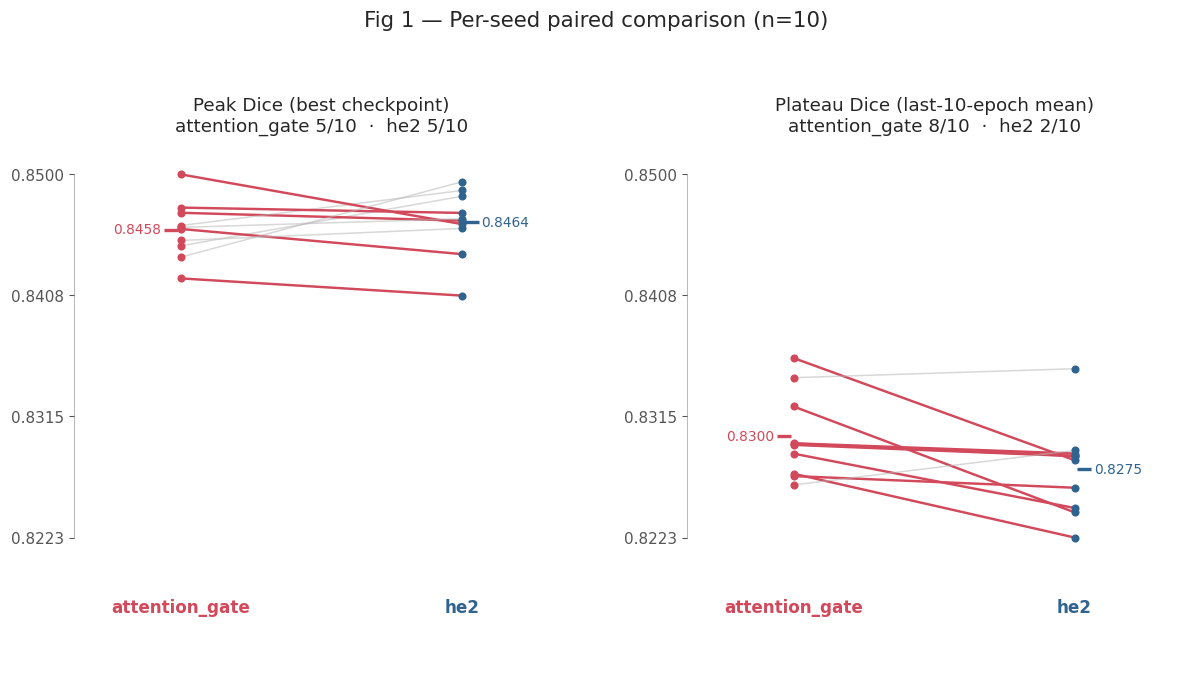

In [4]:
plot_paired_slopegraph(
    runs, SLOPE_METRICS,
    arch_a=AG, arch_b=HE2, seeds=SEEDS, palette=PALETTE,
    title=f'Fig 1 — Per-seed paired comparison (n={N})',
    save_path=FIG_DIR / 'E2_fig1_paired_slopegraph.png',
);

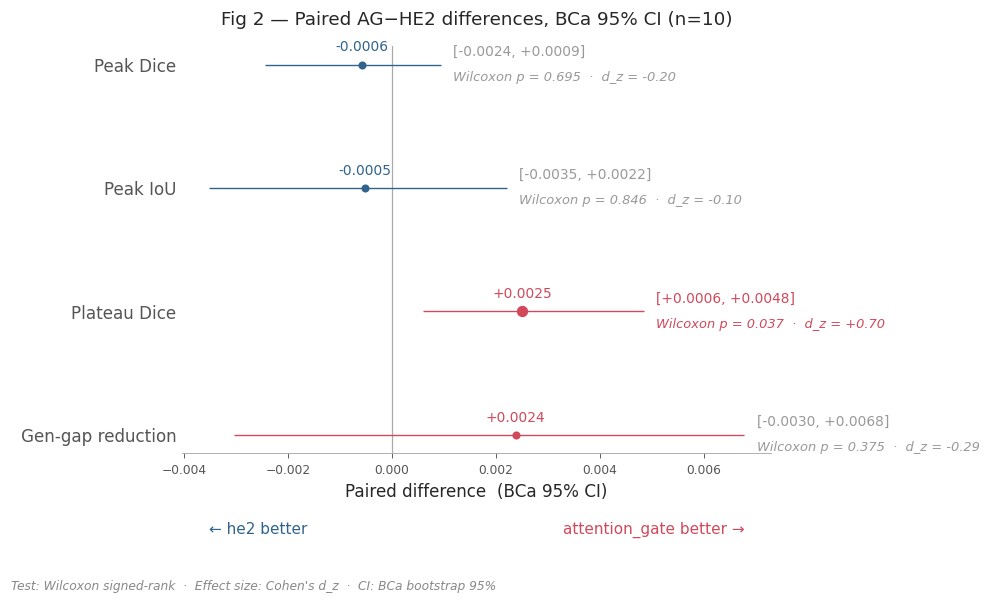

In [ ]:
plot_paired_forest(
    results, FOREST_SPECS,
    arch_a=AG, arch_b=HE2, n=N, palette=PALETTE,
    title=f'Fig 2 — Paired AG−HE2 differences, BCa 95% CI (n={N})',
    save_path=FIG_DIR / 'E2_fig2_forest_paired_diff.png',
);

## 5. Decision

> **Lock `classical` encoder + `attention_gate` merge at `lr = 3e-4`.**

| Priority | Criterion | AG | HE2 | Status (n = 10) |
|---|---|---|---|---|
| 1 | **Plateau Dice — *primary*** (8/10 seeds) | **0.8300** | 0.8275 | AG **confirmed** — p = 0.037, CI [+0.0006, +0.0048], d_z = +0.70; passes pre-registered primary (k = 1, α = 0.05) ✓ |
| 2 | Peak Dice / IoU (deployed checkpoint) | 0.8458 | **0.8464** | tie — Δ ≈ −0.0006, p = 0.70 / 0.85, CI spans 0 |
| 3 | Generalisation gap | 0.092 | 0.094 | tie — p = 0.38, CI spans 0 |
| 4 | Training throughput ‡ | 119.7 sps | **135.3 sps** | HE2 **confirmed** — p = 0.002, standalone (k = 1, α = 0.05) ✓ |

‡ Training cost, not model quality — a separate standalone test.

**Rationale.** AG wins the one pre-registered model-quality axis (plateau stability); peak accuracy is a dead tie; no secondary metric survives Holm correction. HE2's only confirmed advantage is a 13 % throughput edge — iteration cost, not deployed accuracy — so it does not override a model-quality result.

**Honest read.** AG's edge is *real but modest*: one confirmed axis (medium effect, d_z = 0.70, but with a wide CI [0.01, 1.24] and a borderline t-test cross-check at p = 0.054) and zero advantage on the deployed peak metric. `he2` stays fully defensible when compute is the binding constraint — statistically indistinguishable on peak Dice and 13 % faster.

## 6. Next steps

1. **Test-set evaluation (highest priority).** Every E1/E2 number is *validation* Dice, and the funnel was selected on validation (optimistic by construction). Evaluate AG (and the HE2 runner-up) on the official ISIC-2017 test set across all 10 seeds; report test Dice/IoU with bootstrap CIs before any deployment claim. A test-set tie would hand the decision to HE2's speed.
2. **The architecture screen is saturated — change levers.** Both finalists sit at ~0.846 peak Dice with a ~0.09 train−val gap; every encoder/merge difference is ≤ 0.0025 Dice. The productive levers now are regularisation, augmentation strength, loss weighting, and threshold calibration — not block topology.
3. **Measure inference cost directly.** Profile inference latency, parameter count, and exported size for `attention_gate` (`export_onnx.py`). Training throughput (HE2 +13 %) is not a reliable proxy for inference overhead.